In [19]:
# Load and preprocess data
import os
import pandas as pd
import glob

# Define the path to the label files
label_dir = '../data/raw/train/labels/'

# Get all label files
label_files = glob.glob(os.path.join(label_dir, '*.txt'))

# # Function to parse a label file
# def parse_label_file(file_path):
#     with open(file_path, 'r') as f:
#         lines = f.readlines()
#     data = []
#     for line in lines:
#         parts = line.strip().split()
#         if len(parts) == 5:
#             class_id, x_center, y_center, width, height = parts
#             data.append({
#                 'file': os.path.basename(file_path),
#                 'class_id': int(class_id),
#                 'x_center': float(x_center),
#                 'y_center': float(y_center),
#                 'width': float(width),
#                 'height': float(height)
#             })
#     return data

# # Parse all label files and create a DataFrame
# all_data = []
# for file in label_files:
#     all_data.extend(parse_label_file(file))

# df = pd.DataFrame(all_data)

# # Basic preprocessing: remove rows with missing values
# df.dropna(inplace=True)

# # Show the first few rows
# df.head()

['../data/raw/train/labels\\image1317_jpg.rf.525527a5d50226950779297fc4cad8d6.txt', '../data/raw/train/labels\\image19_jpeg.rf.f285863b4c95d700a145e55a0d06fec5.txt', '../data/raw/train/labels\\image281_jpg.rf.66d3bfec1268c92b0b57850292f13ce6.txt', '../data/raw/train/labels\\image1363_jpg.rf.6e695693366d68cd56c4b0a147a9bf8b.txt', '../data/raw/train/labels\\image123_jpg.rf.612674040ec5c323caea45f0b831e437.txt', '../data/raw/train/labels\\image501_jpg.rf.4c0b7078dd4a28a16756aace255d4504.txt', '../data/raw/train/labels\\image175_jpg.rf.1a421ad23915928b7b40ffe4601daff3.txt', '../data/raw/train/labels\\image600_jpg.rf.894d03327ac0ba4b1cb2732b24dae665.txt', '../data/raw/train/labels\\image448_jpg.rf.8ef9b76a6951d53d188609dac9998cb5.txt']
768 1024
640 640
640 640
683 1024
640 640
640 640
640 640
640 640
640 640


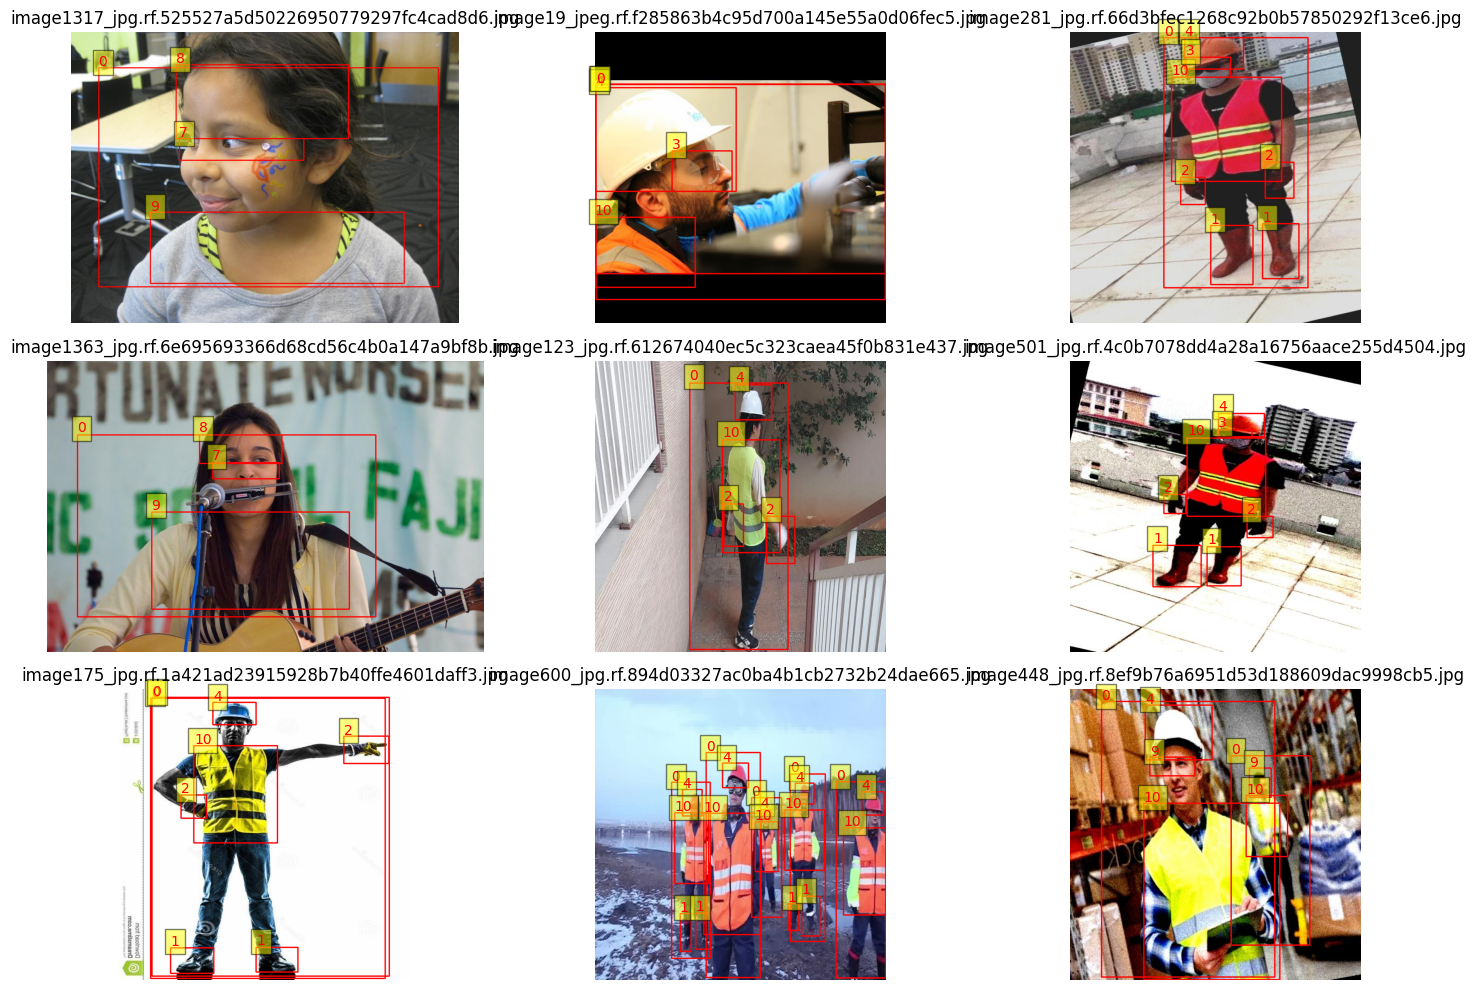

In [20]:
# Visualize 5-6 random images with labels as a grid
import cv2
import matplotlib.pyplot as plt
import random

def parse_label_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()
    data = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            class_id, x_center, y_center, width, height = parts
            data.append({
                'class_id': int(class_id),
                'x_center': float(x_center),
                'y_center': float(y_center),
                'width': float(width),
                'height': float(height)
            })
    return data

# Get corresponding image path from label file name
def get_image_path(label_path):
    image_name = os.path.splitext(os.path.basename(label_path))[0]
    # Try jpg and jpeg extensions
    for ext in ['.jpg', '.jpeg', '.png']:
        img_path = os.path.join('../data/raw/train/images/', image_name + ext)
        if os.path.exists(img_path):
            return img_path
    return None

# Randomly select 6 label files
# sampled_labels = label_files[5:14]
sampled_labels = random.sample(label_files, 9)
print(sampled_labels)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, label_path in enumerate(sampled_labels):
    img_path = get_image_path(label_path)
    if img_path is None:
        axes[idx].set_title('Image not found')
        axes[idx].axis('off')
        continue
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    print(h, w)
    labels = parse_label_file(label_path)
    for obj in labels:
        # Convert normalized coordinates to pixel values
        x = int(obj['x_center'] * w)
        y = int(obj['y_center'] * h)
        bw = int(obj['width'] * w)
        bh = int(obj['height'] * h)
        x1 = int(x - bw / 2)
        y1 = int(y - bh / 2)
        x2 = int(x + bw / 2)
        y2 = int(y + bh / 2)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        axes[idx].text(x1, y1-5, str(obj['class_id']), color='red', fontsize=10, bbox=dict(facecolor='yellow', alpha=0.5))
    axes[idx].imshow(img)
    axes[idx].set_title(os.path.basename(img_path))
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import cv2
import os
import glob
import random
import numpy as np

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [31]:
class PPEDataset(Dataset):
    def __init__(self, label_files, img_dir, target_size=(640, 480), augment=False):
        self.label_files = label_files
        self.img_dir = img_dir
        self.target_size = target_size
        self.augment = augment
        from torchvision.transforms import v2 as T2
        base_transforms = [
            T2.ToImage(),
            T2.Resize(self.target_size)
        ]
        aug_transforms = [
            T2.RandomHorizontalFlip(),
            T2.RandomVerticalFlip()
        ] if augment else []
        self.transforms = T2.Compose(base_transforms + aug_transforms)

    def parse_label_file(self, file_path):
        with open(file_path, 'r') as f:
            lines = f.readlines()
        data = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x_center, y_center, width, height = parts
                data.append([
                    float(x_center),
                    float(y_center),
                    float(width),
                    float(height)
                ])
        return data

    def get_image_path(self, label_path):
        image_name = os.path.splitext(os.path.basename(label_path))[0]
        for ext in ['.jpg', '.jpeg', '.png']:
            img_path = os.path.join(self.img_dir, image_name + ext)
            if os.path.exists(img_path):
                return img_path
        return None

    def __len__(self):
        return len(self.label_files)

    def __getitem__(self, idx):
        label_path = self.label_files[idx]
        img_path = self.get_image_path(label_path)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        labels = self.parse_label_file(label_path)
        orig_h, orig_w, _ = img.shape
        # Convert YOLO (x_center, y_center, w, h) normalized to absolute pixel values
        boxes = []
        for box in labels:
            x_c, y_c, w, h = box
            x_c *= orig_w
            y_c *= orig_h
            w *= orig_w
            h *= orig_h
            # Convert to (x_min, y_min, x_max, y_max)
            x_min = x_c - w / 2
            y_min = y_c - h / 2
            x_max = x_c + w / 2
            y_max = y_c + h / 2
            boxes.append([x_min, y_min, x_max, y_max])
        boxes = torch.tensor(boxes, dtype=torch.float32)
        # Compose target dict for v2 transforms
        target = {"boxes": boxes, "labels": torch.ones((len(boxes),), dtype=torch.int64)}
        # Apply v2 transforms
        img, target = self.transforms(img, target)
        # Convert boxes back to YOLO normalized format
        h, w = img.shape[1:]
        yolo_boxes = []
        for box in target["boxes"]:
            x_min, y_min, x_max, y_max = box.tolist()
            x_c = (x_min + x_max) / 2 / w
            y_c = (y_min + y_max) / 2 / h
            bw = (x_max - x_min) / w
            bh = (y_max - y_min) / h
            yolo_boxes.append([x_c, y_c, bw, bh])
        label_tensor = torch.tensor(yolo_boxes, dtype=torch.float32)
        return img, label_tensor


Image: image945_jpg.rf.ee8fba89ba7e27b6ca969b9658ca3b6b.jpg, Size: 640x640
torch.Size([3, 640, 480])
640 480


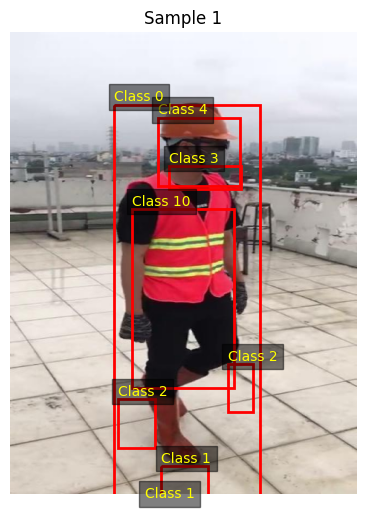

Image: image791_jpg.rf.42f555ca63762efeed02f474d4716a8f.jpg, Size: 640x640
torch.Size([3, 640, 480])
640 480


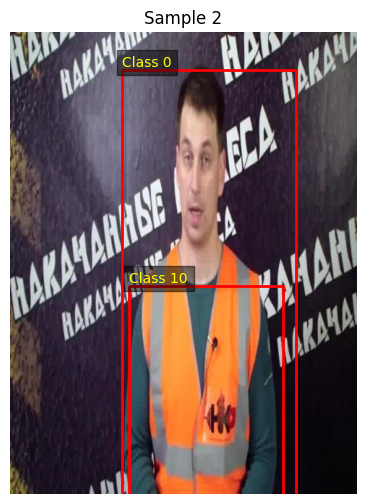

Image: image1329_jpg.rf.38b97cca731135c1c76c10948dc4a119.jpg, Size: 1024x847
torch.Size([3, 640, 480])
640 480


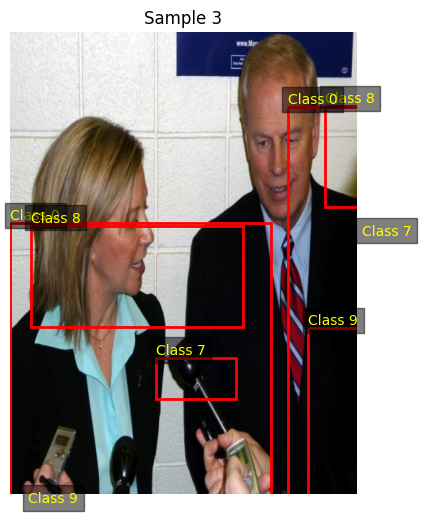

Image: image332_jpg.rf.18b4b6fb4240fd8eec9c711bd0f80489.jpg, Size: 640x640
torch.Size([3, 640, 480])
640 480


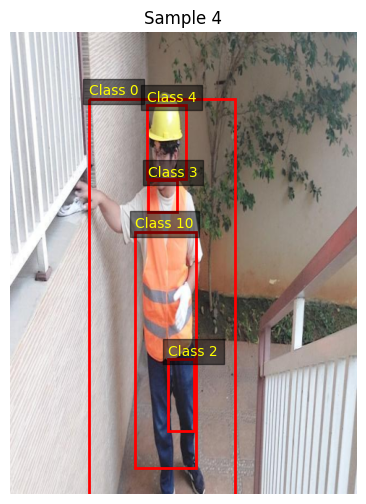

Image: image1075_jpg.rf.0f885a5d57a63fa61fea67ffcd2144e2.jpg, Size: 640x640
torch.Size([3, 640, 480])
640 480


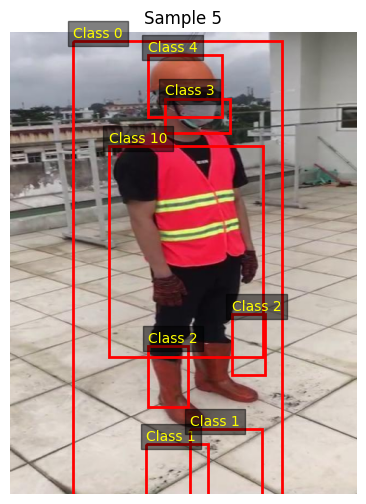

Image: image983_jpg.rf.ae5f6c3ce1048edc50efc898cf6de1bd.jpg, Size: 640x640
torch.Size([3, 640, 480])


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Plot images and bounding boxes from ppe_loader
num_samples = 5
for i, (img_tensor, label_tensor) in enumerate(ppe_loader):
    if i >= num_samples:
        break
    img = img_tensor[0].permute(1, 2, 0).numpy()  # Convert to HWC, RGB
    h, w, _ = img.shape
    print(h, w)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    for label in label_tensor[0]:
        class_id, x_center, y_center, width, height = label.tolist()
        # Convert normalized to pixel coordinates
        x = x_center * w
        y = y_center * h
        bw = width * w
        bh = height * h
        x1 = int(x - bw / 2)
        y1 = int(y - bh / 2)
        x2 = int(x + bw / 2)
        y2 = int(y + bh / 2)
        plt.gca().add_patch(plt.Rectangle((x1, y1), bw, bh, edgecolor='red', facecolor='none', linewidth=2))
        plt.text(x1, y1-5, f'Class {int(class_id)}', color='yellow', fontsize=10, bbox=dict(facecolor='black', alpha=0.5))
    plt.axis('off')
    plt.title(f'Sample {i+1}')
    plt.show()